In [1]:
#Libraries USED
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Load Dataset
df = pd.read_excel("online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
#Basic INFORMATION
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nGeneral Information:")
df.info()

Shape of Dataset:
(525461, 8)

Column Names:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

General Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  

In [4]:
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


In [24]:
duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)
duplicate_rows = df[df.duplicated()]

print("Duplicate Rows:",duplicate_rows.head())

Number of Duplicate Rows: 6865
Duplicate Rows:     Invoice StockCode                        Description  Quantity  \
371  489517     21912           VINTAGE SNAKES & LADDERS         1   
383  489517     22130   PARTY CONE CHRISTMAS DECORATION          6   
384  489517     22319  HAIRCLIPS FORTIES FABRIC ASSORTED        12   
385  489517     21913     VINTAGE SEASIDE JIGSAW PUZZLES         1   
386  489517     21821   GLITTER STAR GARLAND WITH BELLS          1   

            InvoiceDate  Price  Customer ID         Country  Revenue    Month  
371 2009-12-01 11:34:00   3.75      16329.0  United Kingdom     3.75  2009-12  
383 2009-12-01 11:34:00   0.85      16329.0  United Kingdom     5.10  2009-12  
384 2009-12-01 11:34:00   0.65      16329.0  United Kingdom     7.80  2009-12  
385 2009-12-01 11:34:00   3.75      16329.0  United Kingdom     3.75  2009-12  
386 2009-12-01 11:34:00   3.75      16329.0  United Kingdom     3.75  2009-12  


In [ ]:
# missing

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [7]:
#Add Revenue Column
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [9]:
#Top 10 Best Selling Products (Quantity)
top_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_quantity)

Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64


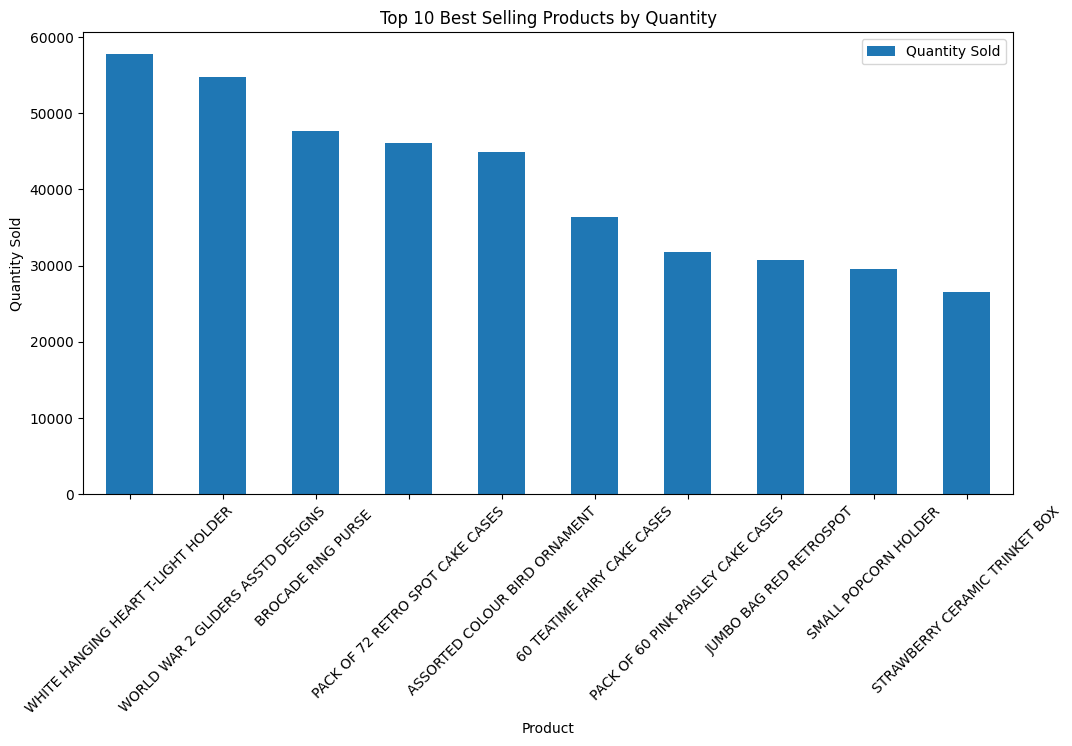

In [26]:
#Plot for top 10 Products by sale Quantity
plt.figure(figsize=(12,6))

top_quantity.plot(kind="bar",label="Quantity Sold")

plt.title("Top 10 Best Selling Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [11]:
top_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_revenue)

Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36699.61
Name: Revenue, dtype: float64


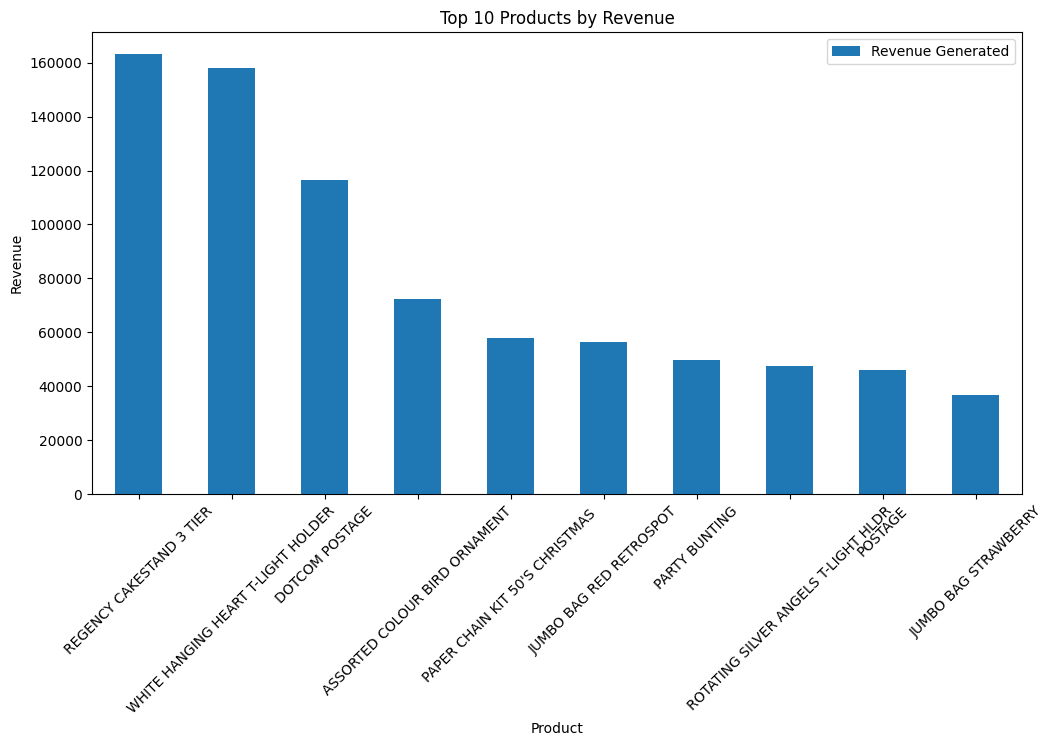

In [27]:
plt.figure(figsize=(12,6))

top_revenue.plot(kind="bar", label="Revenue Generated")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [13]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: Revenue, dtype: float64

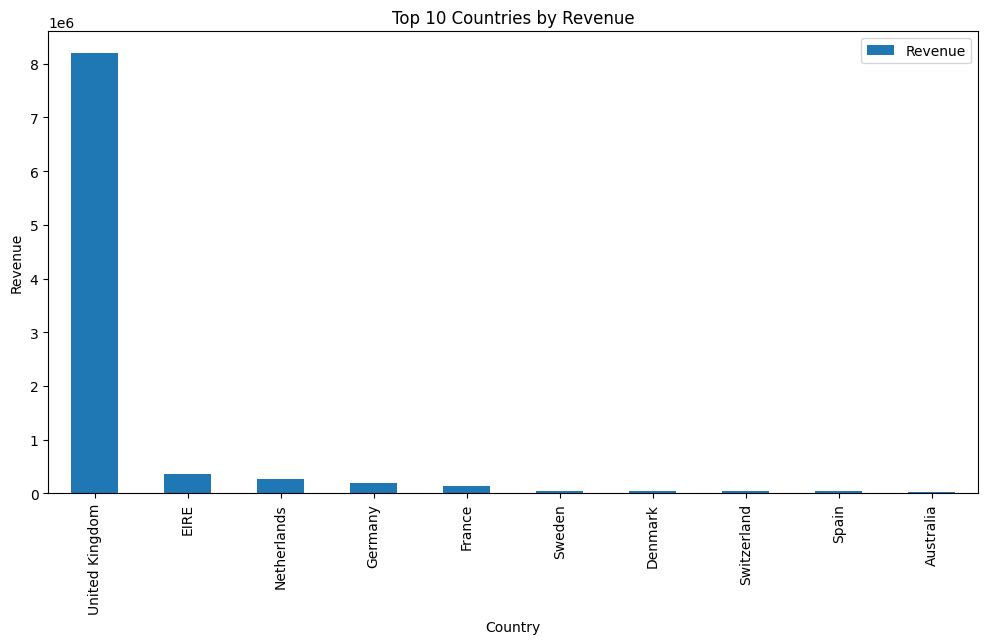

In [28]:
plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.legend()
plt.show()

In [15]:
#Monthly Revenue Trend
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
)

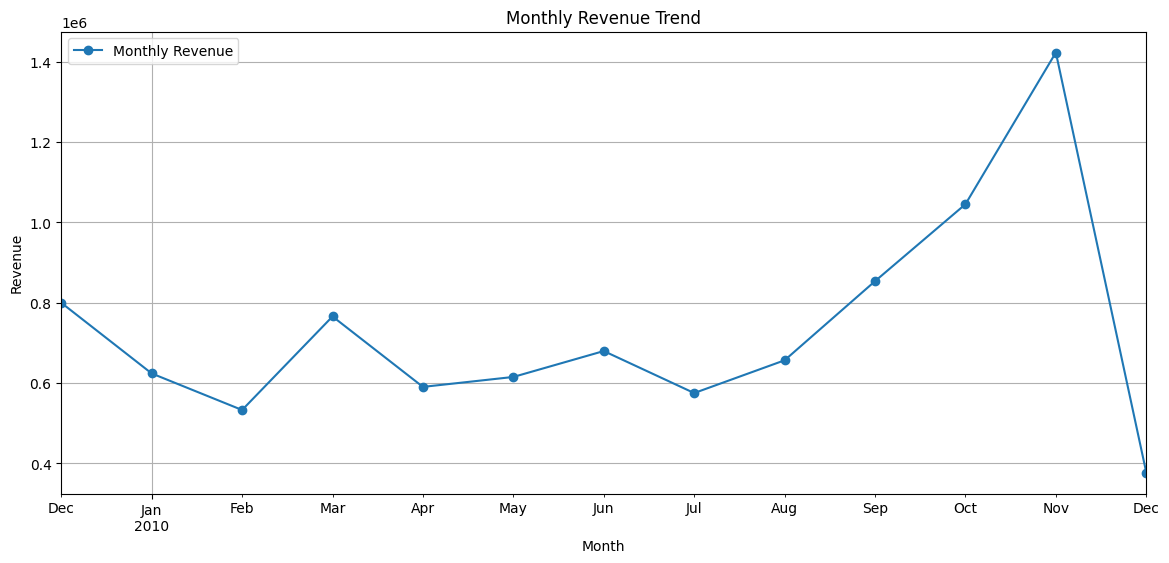

In [31]:
plt.figure(figsize=(14,6))

monthly_sales.plot(marker="o",label="Monthly Revenue")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

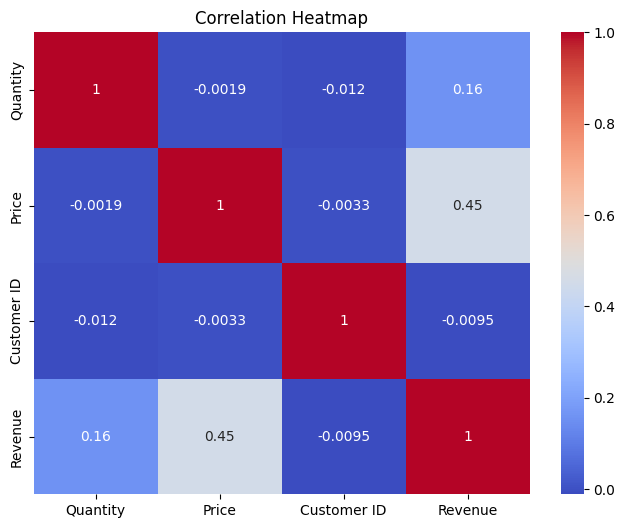

In [17]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

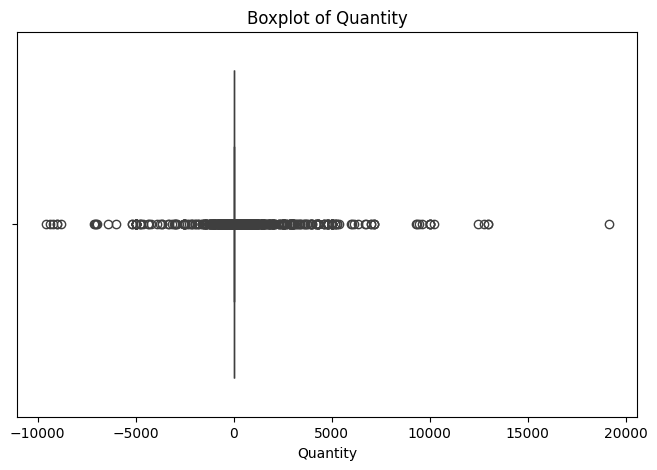

In [18]:
#Boxplot for Quantity
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Quantity"])

plt.title("Boxplot of Quantity")

plt.show()

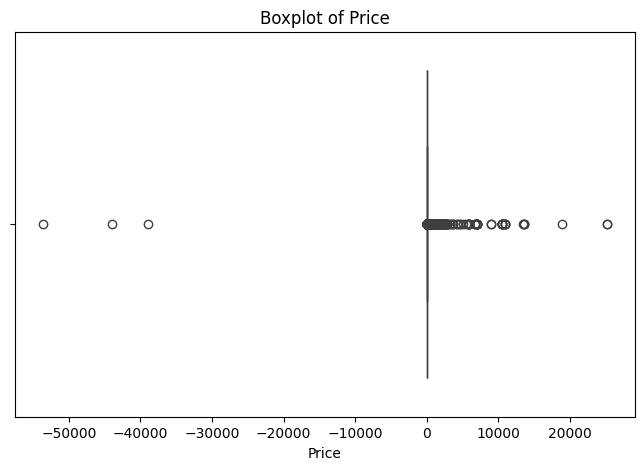

In [19]:
#Boxplot for Price
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Price"])

plt.title("Boxplot of Price")

plt.show()

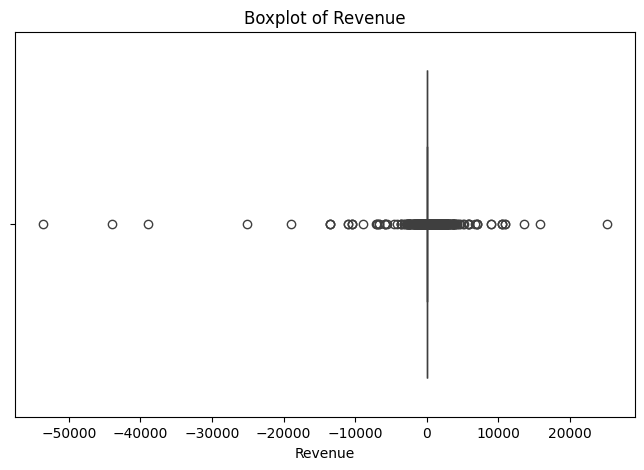

<Figure size 1000x1000 with 0 Axes>

In [20]:
#Boxplot for Revenue
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Revenue"])

plt.title("Boxplot of Revenue")
plt.figure(figsize=(10,10))
plt.show()

In [21]:
print("Business Insights")

print("""
1. The highest-selling products can be identified by total quantity sold.

2. The products generating the most revenue may differ from those with the highest quantity sold due to differences in price.

3. Sales are concentrated in a few countries, indicating the retailer's strongest markets.

4. Monthly revenue trends help identify seasonal peaks and periods of lower sales.

5. Boxplots reveal the presence of outliers in Quantity, Price, and Revenue, which may represent bulk purchases, returns, or unusually high-value transactions.
""")

Business Insights

1. The highest-selling products can be identified by total quantity sold.

2. The products generating the most revenue may differ from those with the highest quantity sold due to differences in price.

3. Sales are concentrated in a few countries, indicating the retailer's strongest markets.

4. Monthly revenue trends help identify seasonal peaks and periods of lower sales.

5. Boxplots reveal the presence of outliers in Quantity, Price, and Revenue, which may represent bulk purchases, returns, or unusually high-value transactions.

